In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = '1405_long'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(2e1)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,u_par,C_rate,SOC
0,17.046,2.787,0.460
1,21.084,4.542,0.370
2,28.287,3.852,0.544
3,5.953,3.160,0.691
4,12.364,2.216,0.578
...,...,...,...
9995,3.118,2.602,0.291
9996,27.880,2.880,0.849
9997,3.222,4.588,0.166
9998,25.080,2.665,0.696


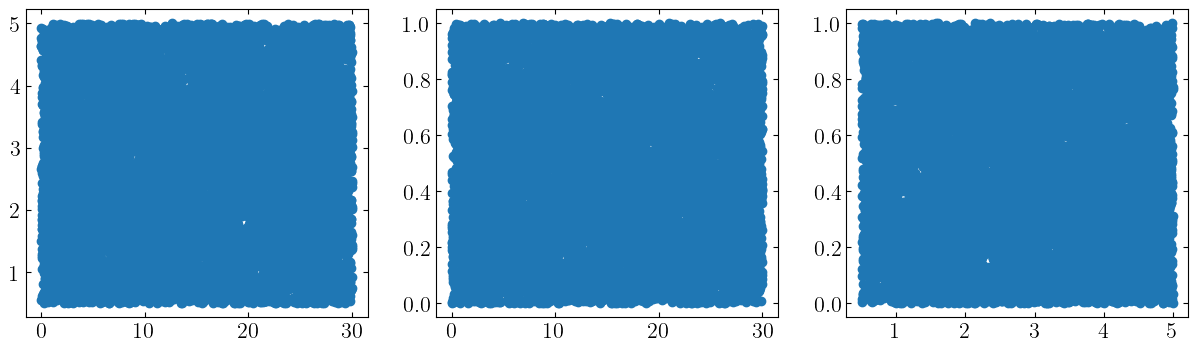

In [3]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('lhs_element.csv', usecols=['u_par', 'C_rate', 'SOC'])

f, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[2].plot(df['C_rate'],df['SOC'], 'o')

display(df)

In [4]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)

def sample_nn(c_rate, u_per, soc, s):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    sdot = sdot_nn(c_rate, u_per, soc, s)
    return R0.item(), R1.item(), C1.item(), k.item(), sdot.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),5+4))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        s = 0
        r0, r1,c1,k,sdot = sample_nn(c_rate, u_per, soc, s)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], sdot / ref_values['s'], c_rate, u_per, soc,s]
    return samples

samples = generate_data(df.values)


100%|██████████| 10000/10000 [00:09<00:00, 1003.44it/s]


In [5]:
cols = VARIABLES + ['C', 'u_per', 'soc', 's_val']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples

data['u_per'] =  data['u_per'] / 30
data['C'] =  data['C'] / 5

data.describe() 

,R0,R1,C1,k,s,C,u_per,soc,s_val
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.0
mean,0.807749,4.251322,6.338343,2.802212,0.489320,0.550001,0.499999,0.50000,0.0
std,0.268592,6.906494,4.752930,0.342743,0.213736,0.259820,0.288690,0.28869,0.0
min,0.700000,0.474043,0.533203,2.274877,0.036171,0.100000,0.000033,0.00000,0.0
25%,0.700000,0.662648,1.773943,2.494504,0.318703,0.325000,0.250042,0.25000,0.0
50%,0.700000,0.834155,5.263081,2.761256,0.491126,0.550000,0.499983,0.50000,0.0
75%,0.700000,1.902795,10.752081,3.080579,0.661964,0.775000,0.749950,0.75000,0.0
max,1.500000,19.273393,16.400719,3.539700,0.917391,1.000000,0.999967,1.00000,0.0


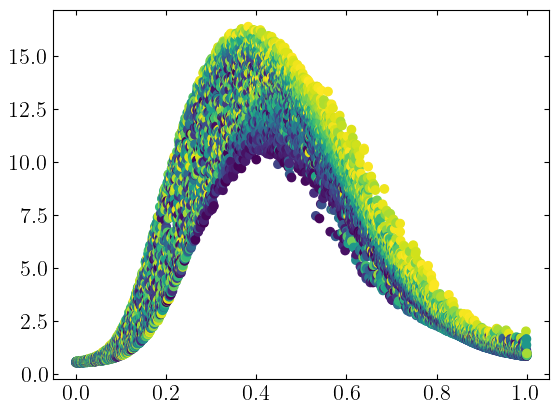

In [6]:
# plotting
arg_soc_sort = np.argsort(df_samples['soc'])
soc_sort = df_samples['soc'].values[arg_soc_sort]
R0_sort = df_samples['R0'].values[arg_soc_sort]
R1_sort = df_samples['R1'].values[arg_soc_sort]
C1_sort = df_samples['C1'].values[arg_soc_sort]
k_sort = df_samples['k'].values[arg_soc_sort]

#plt.plot(soc_sort, R0_sort, '-', label='R0')
#plt.plot(soc_sort, R1_sort, '-', label='R1')
plt.scatter(soc_sort, C1_sort, c = df_samples['u_per'].values[arg_soc_sort], label='C1')
#plt.plot(soc_sort, k_sort, '-', label='k')

# Importing data

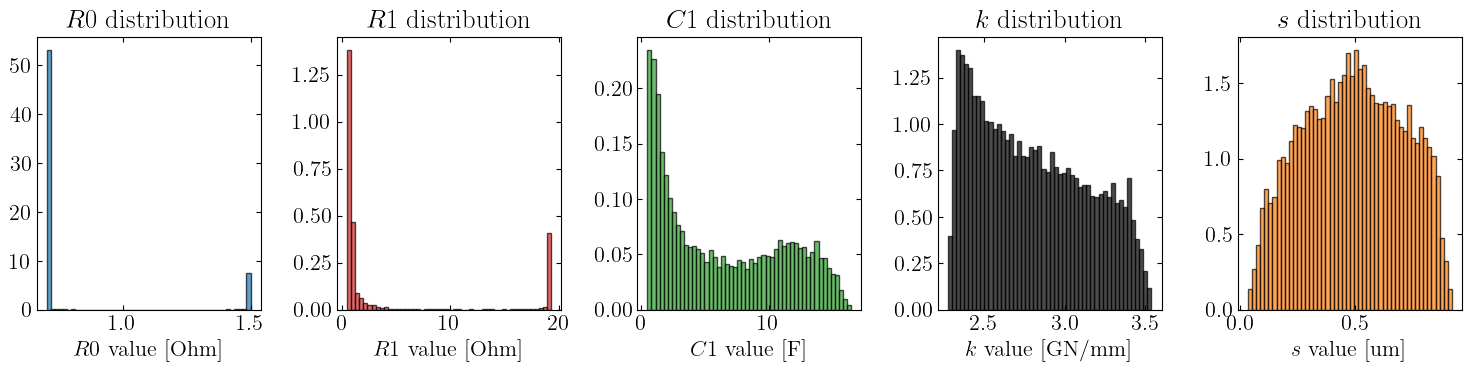

In [7]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

# f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

# for i, var in enumerate(VARIABLES):
#     ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
#     ax[i].set_title(f'${var}$ distribution')
#     ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
# plt.tight_layout()
# plt.show()

In [8]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values #/ REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values #/ REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values #/ REF_VALUES['C1']
    Y_k  = d_frame['k'].values  #/ REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [9]:
split_train = int(len(data) * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[:split_train]
    data_test   = data[split_train:]

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 8000
No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 2000


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

In [10]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_1405_long...
Settings: iterations=20, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


KeyboardInterrupt: 

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id R1_1405_test...
Settings: iterations=2000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=47.26334
Equation: 4.2281146

Model 1: Complexity=3, Loss=44.682705
Equation: 4.727146 - x2

Model 2: Complexity=4, Loss=28.893105
Equation: cube(2.1656108 - x2)

Model 3: Complexity=5, Loss=14.446738
Equation: cube(cube(1.4369926 - x2))

Model 4: Complexity=6, Loss=13.602653
Equation: cube((0.7448283 - x2) * 3.7609258)

Model 5: Complexity=7, Loss=11.078099
Equation: cube(square(x2 - 1.3988993)) * x0

Model 6: Complexity=8, Loss=7.886246
Equation: exp(3.2882864 - ((x2 / x0) * 17.008455))

Model 7: Complexity=9, Loss=2.6256223
Equation: exp(3.0497496 - cube((13.732454 * x2) / x0))

Model 8: Complexity=10, Loss=1.1249734
Equation: exp(2.9720504 - cube(cube(x2 * (14.224489 / x0))))

Model 9: Complexity=11, Loss=1.0416453
Equation: exp(cube(1.4382004 - cube(cube((x2 * 11.7703905) / x0))))

Model 10: Complexity=12, Loss=0.545932
Equation: exp(2.9289255 - cube(cube((x2 / x0) * 14.388353))) + 0.86272496

Model 11: Complexity=13, Loss=0.39712444
Equation: exp(6.249

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(6.2494125/((x2*14.597045/x0)**16.943079 - 1*(-2.111568)))
Loss: 0.39712444
Best model complexity: 13


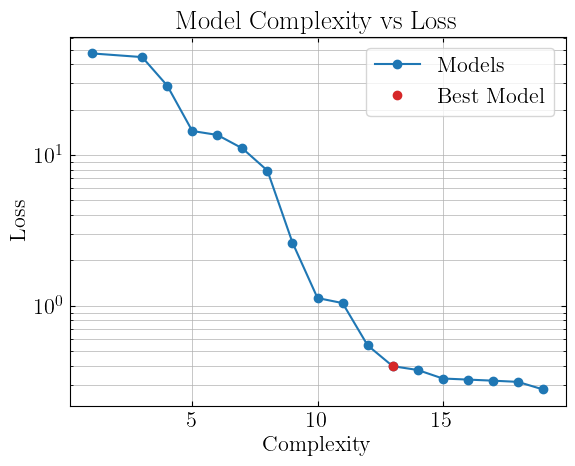

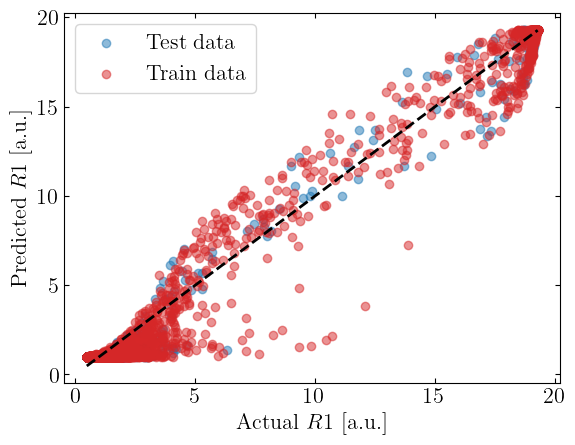

In [ ]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Running symbolic regression for element None with run_id C1_1405_test...
Settings: iterations=2000, populations=30, selection=best
Model 0: Complexity=1, Loss=22.426449
Equation: 6.3374534

Model 1: Complexity=3, Loss=22.03006
Equation: 6.8375034 - x2

Model 2: Complexity=4, Loss=21.24178
Equation: 6.588082 - cube(x2)

Model 3: Complexity=5, Loss=18.263676
Equation: cube(2.057383 - cube(x2))

Model 4: Complexity=6, Loss=13.226397
Equation: (sqrt(x2) - x2) / 0.026030347

Model 5: Complexity=7, Loss=5.9757576
Equation: (x2 * -49.85445) * (x2 + -0.92538315)

Model 6: Complexity=8, Loss=1.9895924
Equation: exp(((x2 + -0.8703578) * x2) * -13.717803)

Model 7: Complexity=9, Loss=1.908749
Equation: cube((x2 * -16.815813) * (sqrt(x2) + -0.98433065))

Model 8: Complexity=10, Loss=1.8102238
Equation: cube(((sqrt(sqrt(x2)) + -1.0064129) * x2) * -27.792776)

Model 9: Complexity=11, Loss=1.5010868
Equation: exp(((sqrt(x2) * (x2 + -1.2459495)) * -11.972765) + -3.8019636)

Model 10: Complexity=12, Lo

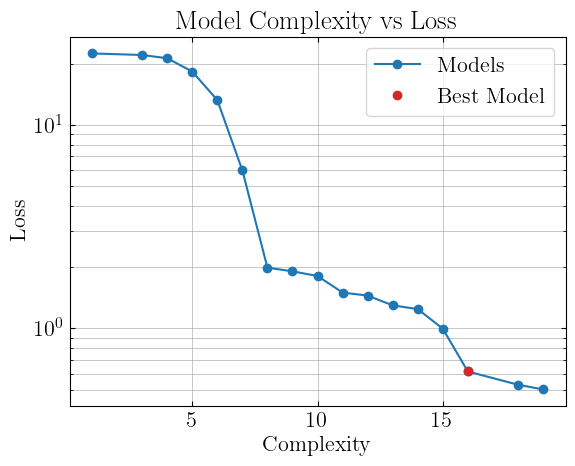

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp((x0 - 45.51424*x2)*(x2**(1/4) - 0.9783595) - 0.45158845/x0)
Loss: 0.61496216
Best model complexity: 16


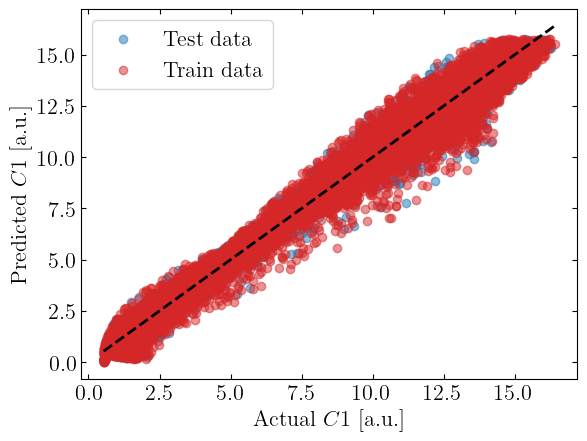

In [ ]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id k_1405_test...
Settings: iterations=2000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.11682984
Equation: 2.803089

Model 1: Complexity=4, Loss=0.056663513
Equation: log(x1 + 5.501778)

Model 2: Complexity=5, Loss=0.0028791304
Equation: (x1 * 0.039100144) + 2.215475

Model 3: Complexity=6, Loss=0.0013198776
Equation: (1.026436 ^ x1) - -1.2851185

Model 4: Complexity=8, Loss=0.0012893495
Equation: ((1.0306677 ^ x1) - -1.8499625) / 1.2410067

Model 5: Complexity=9, Loss=0.0012846644
Equation: (((x1 * 0.00059657515) + 0.021167027) * x1) + 2.3058584

Model 6: Complexity=10, Loss=6.965492e-05
Equation: ((1.0264302 ^ x1) + 1.3465686) + (x2 * -0.12266914)

Model 7: Complexity=12, Loss=6.965491e-05
Equation: ((1.0264302 ^ x1) + 1.3465686) + (square(sqrt(x2)) * -0.12266914)

Model 8: Complexity=13, Loss=9.347919e-06
Equation: ((x1 - (x2 * 3.911335)) * ((x1 * 0.0005958098) + 0.022374727)) + 2.3491292

Model 9: Complexity=15, Loss=9.1821e-06
Equation: ((x1 - ((x2 * 3.8165329) + 1.2891234)) * ((x1 * 0.00059491856) + 0.023147535)) + 2.379091

Model 10: C

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (x1 - 3.911335*x2)*(x1*0.0005958098 + 0.022374727) + 2.3491292
Loss: 9.347919e-06
Best model complexity: 13


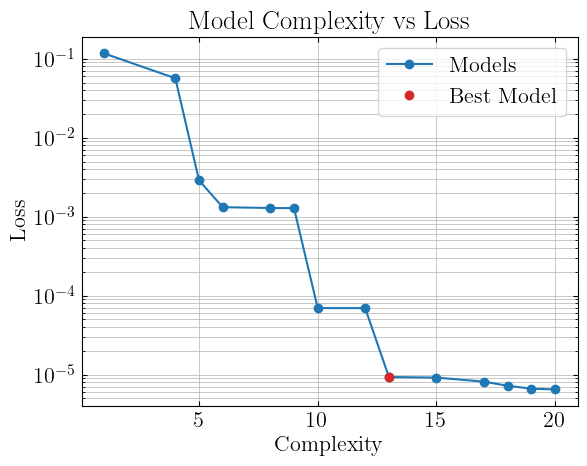

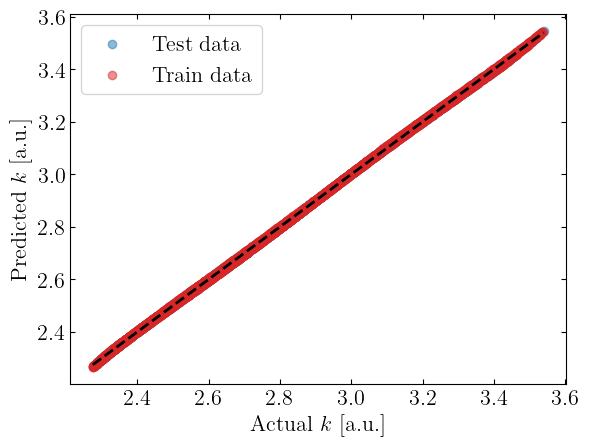

In [ ]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

In [ ]:
# import_reload()
# model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION, elem = 's')
# df_model_s = model_s.equations_
# Param_symbol.print_models(df_model_s)
# Param_symbol.print_best_model(model_s, s = True)
# Param_symbol.pareto_plot(model_s)
# Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [ ]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

NameError: name 'model_s' is not defined

In [ ]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

In [ ]:
# def plot_soc(models, df_samples):
#     C_fixed = df_samples['C'].iloc
#     u_per_fixed = traj['u_per']
#     soc = traj['soc'].values

#     f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

#     for var in VARIABLES:
#         model = models[var]
#         if var == 's':
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
#             Y_true = traj['sdot']
#         else:
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
#             Y_true = traj[var]
#         Y_plot = model.predict(X_plot) * REF_VALUES[var]
#         ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
#         ax[VARIABLES.index(var)].set_xlabel('SOC')
#         ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
#         ax[VARIABLES.index(var)].legend()
#         ax[VARIABLES.index(var)].invert_xaxis()
#     plt.tight_layout()



# traj = get_traj(trajectory_id = 1, test = True)
# plot_soc(MODEL_DICT, traj)

KeyError: 'trajectory'

In [ ]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [ ]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')